# 컴퓨터 비전

### 담당교수 : 장원중

#### 그래프 한글이 깨질때 & 마이너스 부호 사용

In [1]:
import sys, os
from matplotlib import font_manager, rc 
import matplotlib.pyplot as plt

# 한글 폰트 설정 : 윈도우 폰트를 사용하는 경우 
# font_name = font_manager.FontProperties(fname="c:/Windows/Fonts/malgun.ttf").get_name()
# rc('font', family=font_name) 

# 운영체제별 한글 폰트 설정
if os.name == 'posix': # Mac 환경 폰트 설정
    rc('font', family='AppleGothic')
elif os.name == 'nt': # Windows 환경 폰트 설정
    rc('font', family='Malgun Gothic')

plt.rc('axes', unicode_minus=False) # 마이너스 폰트 설정

# 유니코드에서 음수 부호설정
rc('axes', unicode_minus=False)

# 부모 디렉터리의 파일을 가져올 수 있도록 설정
sys.path.append(os.pardir)     

# jupyter에서 matplotlib 그래프를 출력 영역에 표시  
%matplotlib inline 

# 레티나 설정 - 폰트 주변이 흐릿하게 보이는 것을 방지해 글씨가 좀 더 선명하게 보임
%config InlineBackend.figure_format = 'retina'

In [2]:
# 운영체제별 이름 

import platform

platform.system()

'Windows'

# 텐스플로 완전연결층 프로그래밍

In [3]:
# 텐스플로 버전 확인 

import tensorflow as tf

print(tf.__version__)

2.9.2


In [4]:
# 텐스플로 

var = tf.random.uniform([2,3],0,1)
print(var)
print(type(var))

tf.Tensor(
[[0.6958846  0.5313015  0.82864857]
 [0.7197008  0.7114383  0.19039738]], shape=(2, 3), dtype=float32)
<class 'tensorflow.python.framework.ops.EagerTensor'>


## 텐스플로 완전연결층 프로그래밍 : 2층 신경망 

In [ ]:
# - 패션 MNIST 데이터셋을 이용한 2층 완전연결층 인공신경망 구조를 만들어 보자.

### 패션 MNIST 데이터셋 읽어오기 

In [6]:
# tensorflow와 tensorflow.keras를 모듈 읽어오기 

import tensorflow as tf
from tensorflow import keras 
import numpy as np
import matplotlib.pyplot as plt
 
# 패션 MNIST 데이터는 keras의 데이터셋에 있는데 이를 읽어와서 학습용, 테스트 데이터로 구분한다.
fashion_mnist = keras.datasets.fashion_mnist 
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

print(train_images.shape)  # 학습 이미지의 형상 : (60000, 28, 28)
print(train_labels)        # 학습 이미지의 레이블 : [9 0 0 ... 3 0 5] 
print(test_images.shape)   # 테스트 이미지의 형상 : (10000, 28, 28)

(60000, 28, 28)
[9 0 0 ... 3 0 5]
(10000, 28, 28)


In [7]:
# train_images 객체에서 첫번째 이미지의 픽셀 값 출력  
print("형상:", train_images[0].shape)     # (28, 28)
print(train_images[0])     

# 0~255 사이의 픽셀 값인 것을 볼 수 있다.

형상: (28, 28)
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   1   0   0  13  73   0
    0   1   4   0   0   0   0   1   1   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3   0  36 136 127  62
   54   0   0   0   1   3   4   0   0   3]
 [  0   0   0   0   0   0   0   0   0   0   0   0   6   0 102 204 176 134
  144 123  23   0   0   0   0  12  10   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0 155 236 207 178
  107 156 161 109  64  23  77 130  72  15]
 [  0   0   0   0   0   0   0   0   0   0   0   1   0  69 207 223 218 216
  216 163 127 121 122 146 141  88 172  66]
 [  0   0   0   0   0   0   0   0   0   1   1   1  

In [8]:
# train_labels 첫번째 이미지 레이블 출력 

print(train_labels[0])     # 9

# 레이블은 0~9까지의 정수 배열인 것을 알 수 있다. 

9


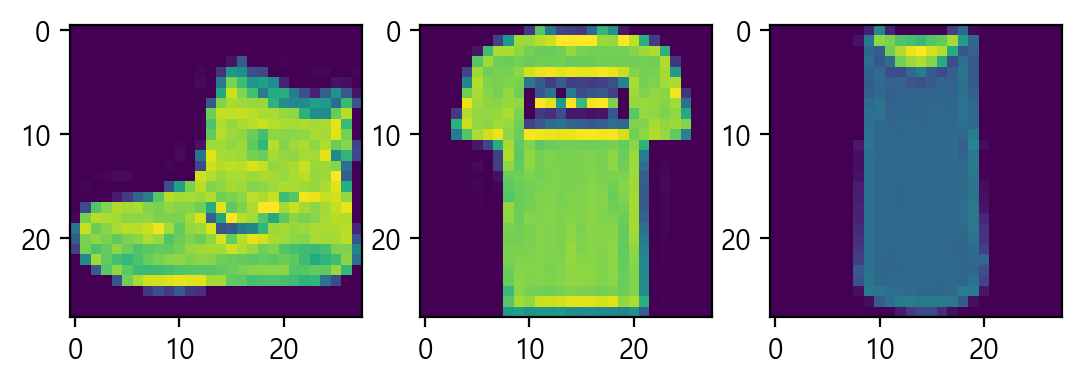

[9 0 0]


In [9]:
# 패션 MNIST 데이터셋 레이블 - 클래스
# 0 : T-shirt/top (티셔츠)
# 1 : Trouser (바지)
# 2 : Pullover (풀오버 상의)
# 3 : Dress (여성용 드레스)
# 4 : Coat (외투)
# 5 : Sandal (샌달)
# 6 : Shirt (셔츠)
# 7 : Sneaker (스니커 운동화)
# 8 : Bag (가방)
# 9 : Ankle boot (발목 부츠)

# 패션 MNIST는 레이블이 있는 이미지 데이터 
#  - 훈련용 데이터 첫 번째, 두 번째, 세 번째 이미지 
fig = plt.figure()
ax1 = fig.add_subplot(1, 3, 1)
ax2 = fig.add_subplot(1, 3, 2)
ax3 = fig.add_subplot(1, 3, 3)

ax1.imshow(train_images[0])       # 첫 번째 훈련용 이미지
ax2.imshow(train_images[1])       # 두 번째 훈련용 이미지
ax3.imshow(train_images[2])       # 세 번째 훈련용 이미지
plt.show()

print(train_labels[0:3])          # [9 0 0] - 훈련용 데이터 첫 번째, 두 번째, 세 번째 데이터의 레이블 

### 2층 인공신경망 계층 구조 구축

In [10]:
# 인공신경망 계층구조 구축
#  - 텐스플로(케라스)의 Dense는 학습을 위한 연결을 밀집된(dense) 구조 혹은 완전연결(Fully connected) 층으로 한다. 

# 2개의 완전연결층을 가진 네트워크 모델 생성 
#  - Flatten 계층 : 2차 입력 (28, 28)을 1차원 784(28x28)으로 변경 
#  - Dense 네트워크 : 출력 128, 활성화함수 = ReLU 
#  - Dense 네트워크 : 출력 10, 활성화함수 = SoftMax

# 2층 신경망 계층구조 
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

### 인공신경망 학습 : 하이퍼파라미터 설정

In [11]:
# 신경망 학습 
#  - 최적화(optimization) 기법 : 아담(adam) 
#  - 손실함수 : sparse_categorical_crossentropy 
#  - 모델 평가 : 정확도(accuracy)

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [12]:
# 신경망 학습 
#  - 반복 횟수 : 30개의 에폭(epoch)

hist = model.fit(train_images, train_labels, epochs=30)

Epoch 1/30
1875/1875 [==============================] - 5s 2ms/step - loss: 3.3359 - accuracy: 0.7164
Epoch 2/30
1875/1875 [==============================] - 4s 2ms/step - loss: 0.6087 - accuracy: 0.7920
Epoch 3/30
1875/1875 [==============================] - 4s 2ms/step - loss: 0.5391 - accuracy: 0.8111
Epoch 4/30
1875/1875 [==============================] - 4s 2ms/step - loss: 0.5186 - accuracy: 0.8202
Epoch 5/30
1875/1875 [==============================] - 4s 2ms/step - loss: 0.4961 - accuracy: 0.8267
Epoch 6/30
1875/1875 [==============================] - 4s 2ms/step - loss: 0.4838 - accuracy: 0.8355
Epoch 7/30
1875/1875 [==============================] - 4s 2ms/step - loss: 0.4760 - accuracy: 0.8368
Epoch 8/30
1875/1875 [==============================] - 4s 2ms/step - loss: 0.4689 - accuracy: 0.8383
Epoch 9/30
1875/1875 [==============================] - 4s 2ms/step - loss: 0.4632 - accuracy: 0.8415
Epoch 10/30
1875/1875 [==============================] - 4s 2ms/step - loss: 0.459

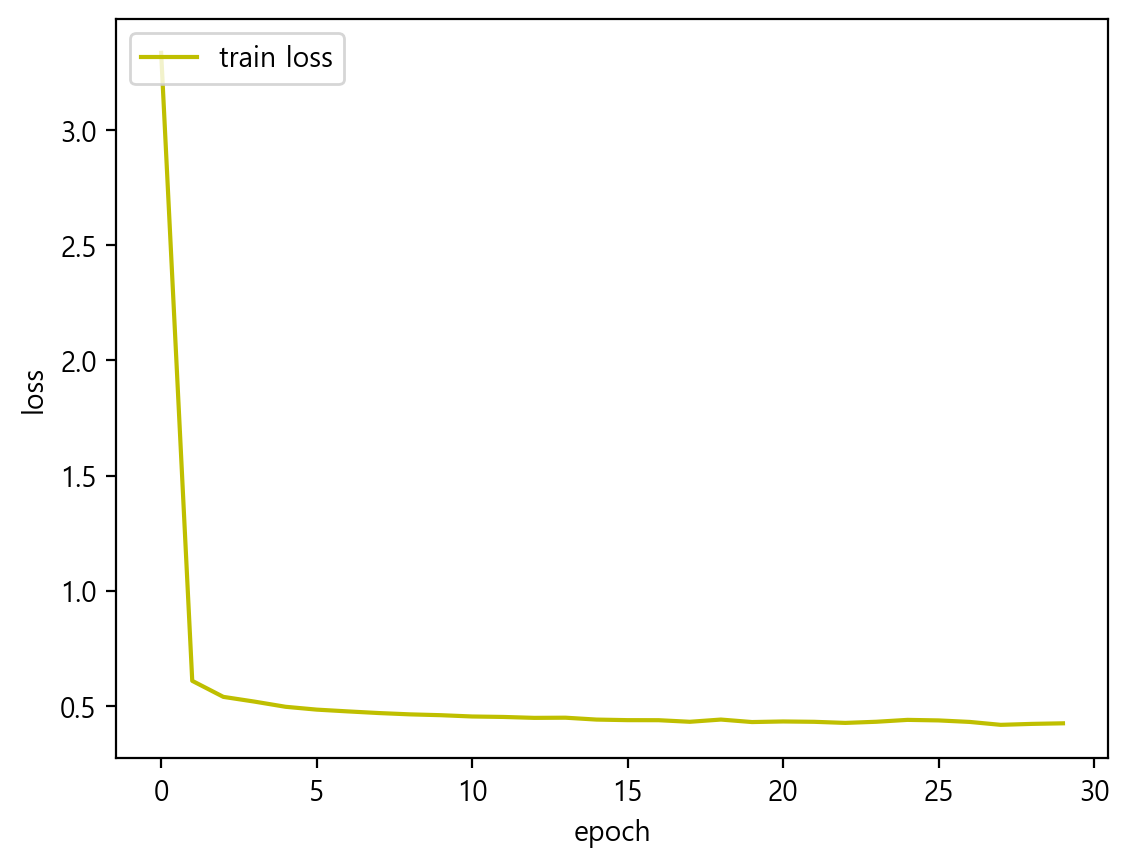

In [13]:
# 학습과정 표시하기 
import matplotlib.pyplot as plt

fig, loss_ax = plt.subplots()

loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
loss_ax.legend(loc='upper left')

plt.show()

In [14]:
# 테스트 데이터를 이용한 모델 평가 

test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)

print('\n테스트 정확도:', test_acc)    # 테스트 정확도: 0.8137000203132629

313/313 - 1s - loss: 0.6422 - accuracy: 0.8303 - 723ms/epoch - 2ms/step

테스트 정확도: 0.830299973487854


In [12]:
import os

print(os.getcwd())

D:\PyWork\CKU202301C\tensorflow


### 학습된 모델 (2층 신경망)  저장

In [13]:
# 학습된 모델 저장하기 

import os

model.save(os.getcwd()+'/model/fashion_dnn2_model.h5')
print("Saved model to disk !!!")

Saved model to disk !!!


In [14]:
# 필요한 패키지와 모듈을 불러오기 

import os
from tensorflow.keras.models import load_model

model = load_model(os.getcwd()+'/model/fashion_dnn2_model.h5')
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense (Dense)               (None, 128)               100480    
                                                                 
 dense_1 (Dense)             (None, 10)                1290      
                                                                 
Total params: 101,770
Trainable params: 101,770
Non-trainable params: 0
_________________________________________________________________


### 학습된 신경망을 새 이미지에 적용하여 예측하기

In [15]:
# 테스트 이미지 형상 

test_images.shape     # (10000, 28, 28)

(10000, 28, 28)

(28, 28)
5


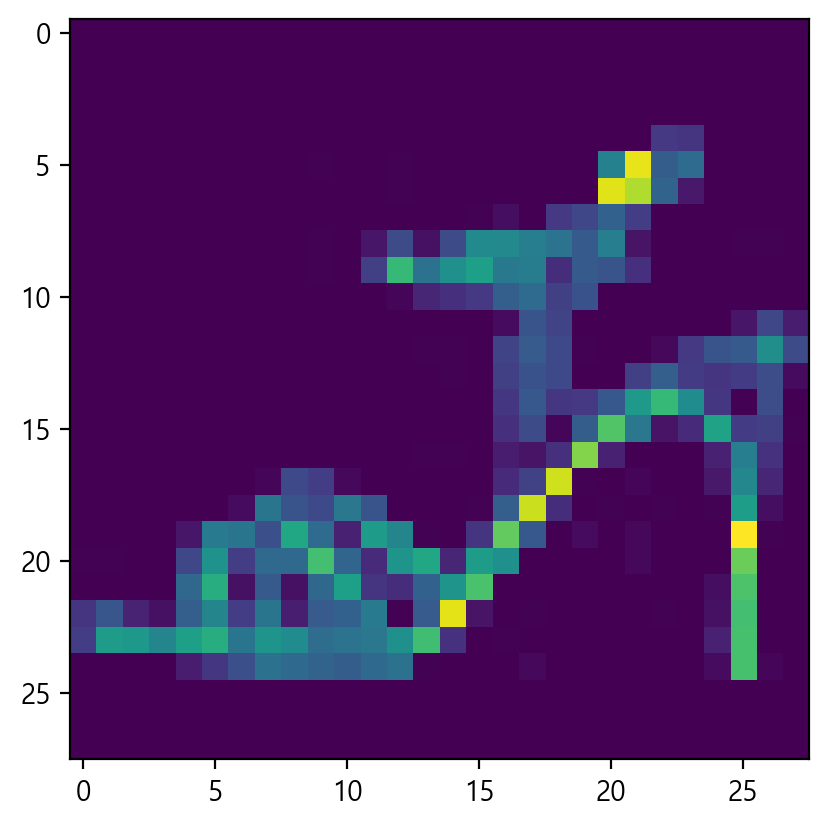

In [16]:
# 패션 MNIST 데이터셋 레이블 - 클래스
# 0 : T-shirt/top (티셔츠)
# 1 : Trouser (바지)
# 2 : Pullover (풀오버 상의)
# 3 : Dress (여성용 드레스)
# 4 : Coat (외투)
# 5 : Sandal (샌달)
# 6 : Shirt (셔츠)
# 7 : Sneaker (스니커 운동화)
# 8 : Bag (가방)
# 9 : Ankle boot (발목 부츠)

# 테스트 데이터에서 무작위로 하나의 이미지를 선택해보자. 

import numpy as np

randIdx = np.random.randint(0, 10000)
print(test_images[randIdx].shape)
plt.imshow(test_images[randIdx])

print(test_labels[randIdx])     # 5 : Sandal (샌달)

In [21]:
# 모델에 테스트 데이터에서 무작위로 선택된 하나의 이미지로 예측해보자. 

print(test_images[randIdx].shape)            # 하나의 이미지 형상 : (28, 28) 

yhat = model.predict(test_images[randIdx])

# 실행 결과 오류가 발생한다. 
#  - 위 코드에서 하나의 이미지 형상은 (28, 28) 이다. 
#  - 하지만, 모델의 신경망 구조에서 3차원 배열 입력을 처리하는 모델을 만들었다. 
#  - 그러므로, 모델에 입력하는 이미지의 형상을 2차원(28, 28)에서 3차원(1, 28, 28)으로 변경하여야 한다.   

(28, 28)


ValueError: in user code:

    File "C:\Users\user\anaconda3\lib\site-packages\keras\engine\training.py", line 2137, in predict_function  *
        return step_function(self, iterator)
    File "C:\Users\user\anaconda3\lib\site-packages\keras\engine\training.py", line 2123, in step_function  **
        outputs = model.distribute_strategy.run(run_step, args=(data,))
    File "C:\Users\user\anaconda3\lib\site-packages\keras\engine\training.py", line 2111, in run_step  **
        outputs = model.predict_step(data)
    File "C:\Users\user\anaconda3\lib\site-packages\keras\engine\training.py", line 2079, in predict_step
        return self(x, training=False)
    File "C:\Users\user\anaconda3\lib\site-packages\keras\utils\traceback_utils.py", line 70, in error_handler
        raise e.with_traceback(filtered_tb) from None
    File "C:\Users\user\anaconda3\lib\site-packages\keras\engine\input_spec.py", line 277, in assert_input_compatibility
        raise ValueError(

    ValueError: Exception

In [22]:
# newaxis는 numpy array의 차원을 늘려준다. 
# - 형상(shape)는 변환전 차원의 합과 변환후 차원의 합이 같아야 한다. 

arr = np.arange(4) 
print(arr.shape)      # (4,)

# make it as row vector by inserting an axis along first dimension
row_vec = arr[np.newaxis, :] 
print(row_vec.shape)  # (1, 4) 

# # make it as column vector by inserting an axis along second dimension
col_vec = arr[:, np.newaxis] 
print(col_vec.shape)  # (4, 1) 

(4,)
(1, 4)
(4, 1)


In [17]:
# 패션 MNIST 데이터셋 레이블 - 클래스
# 0 : T-shirt/top (티셔츠)
# 1 : Trouser (바지)
# 2 : Pullover (풀오버 상의)
# 3 : Dress (여성용 드레스)
# 4 : Coat (외투)
# 5 : Sandal (샌달)
# 6 : Shirt (셔츠)
# 7 : Sneaker (스니커 운동화)
# 8 : Bag (가방)
# 9 : Ankle boot (발목 부츠)

# argmax() : 배열에서 가장 큰 값을 갖는 인덱스를 반환한다.  

# 학습된 모델로 테스트 데이터에서 무작위로 선택된 하나의 이미지로 예측해보자. 
yhat = model.predict(test_images[randIdx][np.newaxis, :, :])     # 이미지 형상을 3차원으로 늘려서 모델에 입력 
print(yhat)

# 클래스를 찾아 출력하게 만들기
yhat = np.argmax(model.predict(test_images[randIdx][np.newaxis, :, :]))
print(yhat)            # 5 

# 클래스 이름을 리스트로 만들기 
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'] 

yhat = np.argmax(model.predict(test_images[randIdx][np.newaxis, :, :]))
print("예측:", class_names[yhat])                   # 예측: Sandal
print("실제:", class_names[test_labels[randIdx]])   # 실제: Sandal

1/1 [==============================] - 0s 141ms/step
[[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]]
1/1 [==============================] - 0s 30ms/step
5
1/1 [==============================] - 0s 32ms/step
예측: Sandal
실제: Sandal


### 발목 부츠 이미지 파일을 읽어 화면 출력하기

(743, 916, 4)


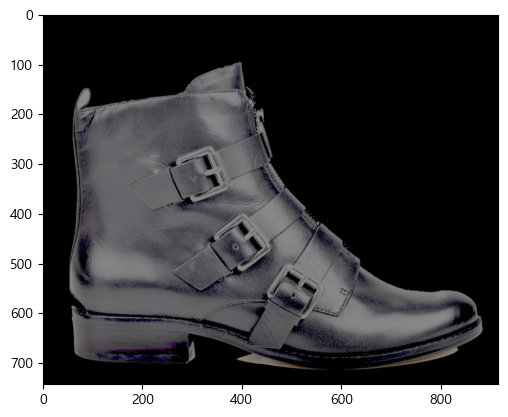

In [26]:
# 발목 부츠 이미지 파일 읽어오기 

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import os

image1 = mpimg.imread(os.getcwd()+'/images/ankle_boot_reverse.png')
plt.imshow(image1)

print(image1.shape)          # 형상 : (743, 916, 4) (높이,가로,채널) - 불투명도 채널까지 포함된 4-채널 이미지 

### 발목 부츠 이미지를 좌우 전환

C:\Users\user\AppData\Local\Temp\ipykernel_17724\1521889683.py:13: DeprecationWarning: FLIP_LEFT_RIGHT is deprecated and will be removed in Pillow 10 (2023-07-01). Use Transpose.FLIP_LEFT_RIGHT instead.
  flp_img = image1.transpose(Image.FLIP_LEFT_RIGHT)


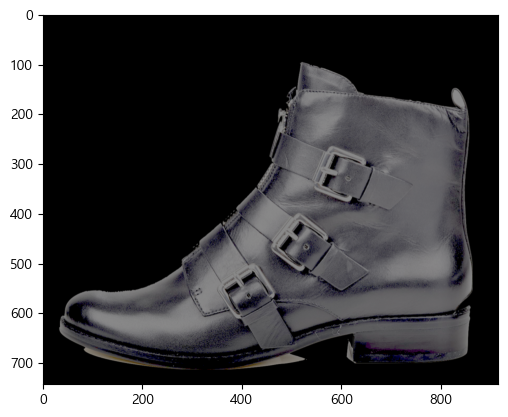

In [27]:
# 이미지 상하, 좌우 대칭 
#  image.transpose(Image.direction*)
#  FLIP_LEFT_RIGHT - 좌우 대칭할 경우 입력해줍니다. 
#  FLIP_TOP_BOTTOM - 상하 대칭일 경우 입력해줍니다. 

from PIL import Image
import matplotlib.pyplot as plt
import os

# 이미지 불러오기
image1 = Image.open(os.getcwd()+'/images/ankle_boot_reverse.png')

flp_img = image1.transpose(Image.FLIP_LEFT_RIGHT)
plt.imshow(flp_img)

C:\Users\user\AppData\Local\Temp\ipykernel_17724\869882282.py:6: DeprecationWarning: FLIP_TOP_BOTTOM is deprecated and will be removed in Pillow 10 (2023-07-01). Use Transpose.FLIP_TOP_BOTTOM instead.
  flp_img = image1.transpose(Image.FLIP_TOP_BOTTOM)


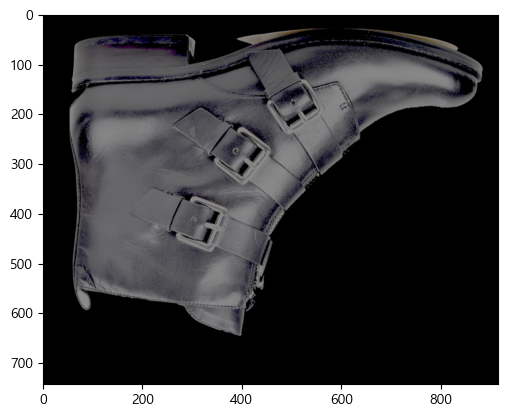

In [28]:
# 이미지 상하, 좌우 대칭 
#  image.transpose(Image.direction*)
#  FLIP_LEFT_RIGHT - 좌우 대칭할 경우 입력해줍니다. 
#  FLIP_TOP_BOTTOM - 상하 대칭일 경우 입력해줍니다. 

flp_img = image1.transpose(Image.FLIP_TOP_BOTTOM)
plt.imshow(flp_img)

C:\Users\user\AppData\Local\Temp\ipykernel_17724\2717099301.py:7: DeprecationWarning: ROTATE_90 is deprecated and will be removed in Pillow 10 (2023-07-01). Use Transpose.ROTATE_90 instead.
  flp_img = image1.transpose(Image.ROTATE_90)


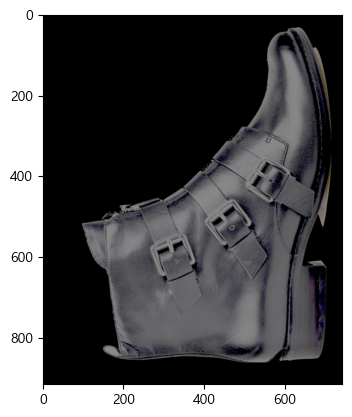

In [29]:
# 이미지 회전하기
#  image.transpose(Image.Rotate_degree*) 
#  ROTATE_90 - 좌측으로 90도 회전
#  ROTATE_180 - 좌측으로 180도 회전
#  ROTATE_270 - 좌측으로 270도 회전

flp_img = image1.transpose(Image.ROTATE_90)
plt.imshow(flp_img)

C:\Users\user\AppData\Local\Temp\ipykernel_17724\3831844246.py:7: DeprecationWarning: ROTATE_180 is deprecated and will be removed in Pillow 10 (2023-07-01). Use Transpose.ROTATE_180 instead.
  flp_img = image1.transpose(Image.ROTATE_180)


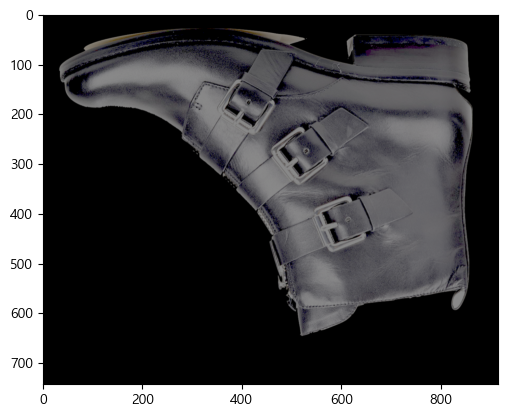

In [30]:
# 이미지 회전하기
#  image.transpose(Image.Rotate_degree*) 
#  ROTATE_90 - 좌측으로 90도 회전
#  ROTATE_180 - 좌측으로 180도 회전
#  ROTATE_270 - 좌측으로 270도 회전

flp_img = image1.transpose(Image.ROTATE_180)
plt.imshow(flp_img)

C:\Users\user\AppData\Local\Temp\ipykernel_17724\982014105.py:7: DeprecationWarning: ROTATE_270 is deprecated and will be removed in Pillow 10 (2023-07-01). Use Transpose.ROTATE_270 instead.
  flp_img = image1.transpose(Image.ROTATE_270)


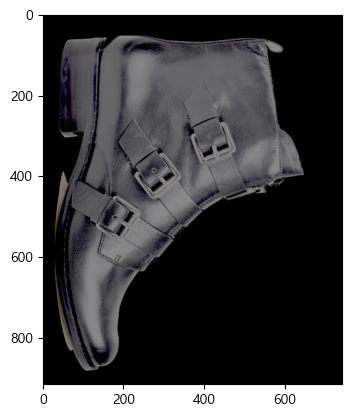

In [31]:
# 이미지 회전하기
#  image.transpose(Image.Rotate_degree*) 
#  ROTATE_90 - 좌측으로 90도 회전
#  ROTATE_180 - 좌측으로 180도 회전
#  ROTATE_270 - 좌측으로 270도 회전

flp_img = image1.transpose(Image.ROTATE_270)
plt.imshow(flp_img)

### 발목 부츠 이미지를 모델에 입력으로 제공해 예측(인식)하기

In [35]:
# OpenCV(Open Source Computer Vision Library)는 오픈소스 컴퓨터비전 및 머신러닝 라이브러리이다.  

# OpenCV 패키지 설치 
!pip3 install opencv-python

     ---------------------------------------- 38.2/38.2 MB 8.6 MB/s eta 0:00:00


(28, 28)


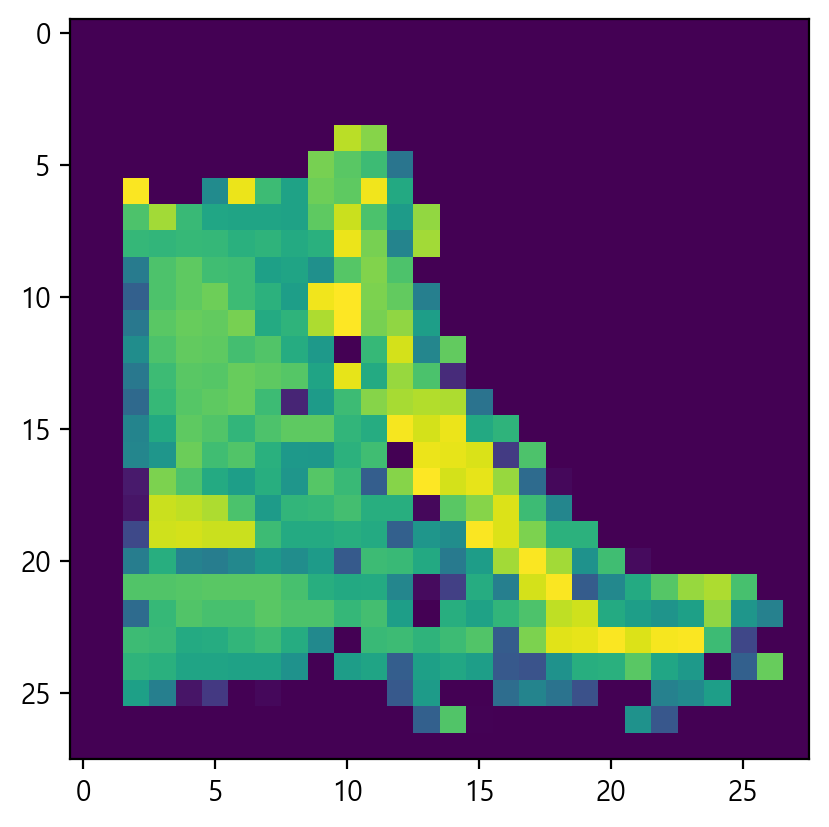

In [18]:
# 발목 부츠 이미지 

# opencv를 이용해 회색조 단일 채널 이미지로 변환하기 

import cv2

img = cv2.imread(os.getcwd()+'/images/ankle_boot_reverse.png', cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (28, 28))
plt.imshow(img)
 
print(img.shape)         # 형상 : (28, 28) 

In [19]:
# 발목 부츠 이미지 형상 변경 : 2차원(28,28) ==> 3차원(1,28,28) 

input_data = img[np.newaxis, :, :]
input_data.shape     # (1, 28, 28)

(1, 28, 28)

In [20]:
# 모델에 적용하여 발목 부츠 이미지를 예측하기 
# - 발목 부츠를 가방으로 잘못 인식 

# 패션 MNIST 데이터셋 레이블 - 클래스
# 0 : T-shirt/top (티셔츠)
# 1 : Trouser (바지)
# 2 : Pullover (풀오버 상의)
# 3 : Dress (여성용 드레스)
# 4 : Coat (외투)
# 5 : Sandal (샌달)
# 6 : Shirt (셔츠)
# 7 : Sneaker (스니커 운동화)
# 8 : Bag (가방)
# 9 : Ankle boot (발목 부츠)

# 모델에 적용하여 발목 부츠 이미지를 예측하기 

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
yhat = np.argmax(model.predict(input_data))
print(class_names[yhat])    # 가방(Bag) 

# 실행 결과 
#  - 가방(Bag)으로 잘못 예측한 것을 알 수 있다. 
#  - 사람이 보기에는 분명히 부츠처럼 보이지만, 기계는 신발의 코가 왼쪽으로 간 것만 보다가 오른쪽으로 간 것을 보면,  
#    이전에 교육받았던 이미지와 전혀 다른 것으로 인식할 수도 있는 것이다. 
#  - 이번에는 발목 부츠 이미지를 좌우 전환해 보자.  

1/1 [==============================] - 0s 27ms/step
Bag


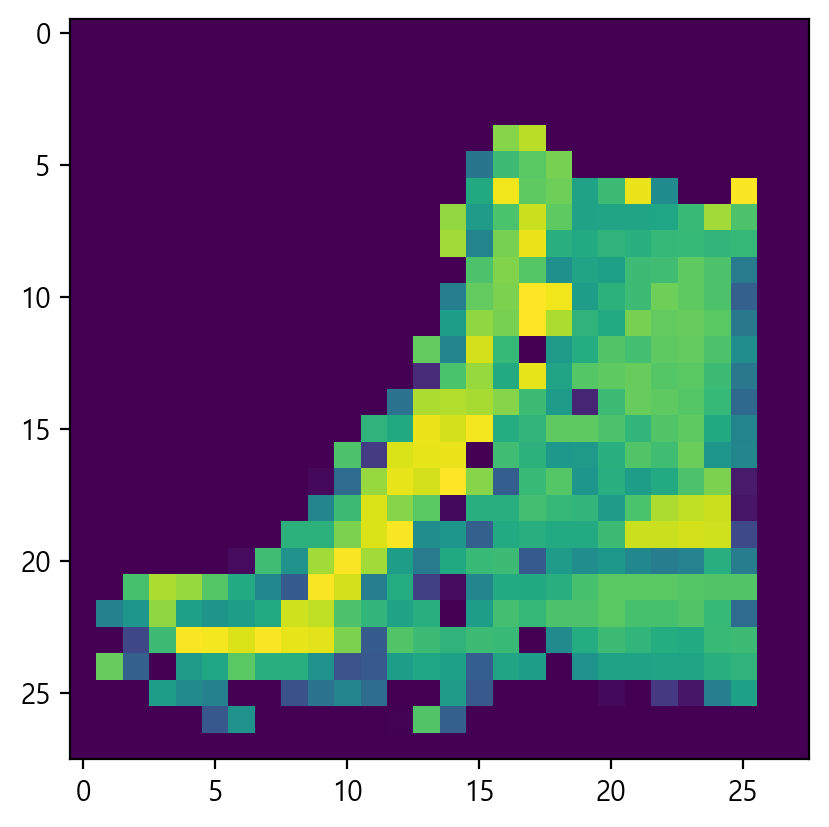

In [21]:
# 발목 부츠 이미지 데이터의 좌우를 전환해보자.

input_mirror = input_data[:, :, ::-1]
plt.imshow(input_mirror[0])

In [22]:
# 발목 부츠 이미지 좌우를 뒤집은 이미지로 예측하기  
#  - 이미지에 적합한 클래스를 인식 

# 패션 MNIST 데이터셋 레이블 - 클래스
# 0 : T-shirt/top (티셔츠)
# 1 : Trouser (바지)
# 2 : Pullover (풀오버 상의)
# 3 : Dress (여성용 드레스)
# 4 : Coat (외투)
# 5 : Sandal (샌달)
# 6 : Shirt (셔츠)
# 7 : Sneaker (스니커 운동화)
# 8 : Bag (가방)
# 9 : Ankle boot (발목 부츠)

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
yhat = np.argmax(model.predict(input_mirror))

print(class_names[yhat])    # 발목 부츠(Ankle boot)

# 실행 결과 
#  - 학습시킨 모델은 데이터의 한계 때문에 오른쪽을 쳐다보는 발목 신발은 상상하지 못하는 것이다.  

1/1 [==============================] - 0s 39ms/step
Ankle boot


### 신경망 학습과 편향 : 학습의 한계

In [ ]:
# 학습 
#  - 입력으로 주어진 데이터에 따라 한계를 가질 수 밖에 없다. 
#  - 훈련용으로 주어진 데이터에서 모든 신발은 왼쪽을 쳐다보고 있었기 때문에 오른쪽을 쳐다보는 발목 부츠가 들어왔을 때, 
#    이것이 신발류라는 것을 인식하지 못하는 것이다. 

# 패션 MNIST 데이터의 경우 배경이 모두 검정으로 처리되어 있기 때문에 또 다른 문제가 발생할 수 있다. 
#  - 배경이 검정색이 아닌 이미지를 입력하면 이 이미지가 명백히 신발인데도 불구하고, 
#    우리가 만들어낸 모델이 운동화나 부츠로 인식하지 못할 가능성이 높다.
#  - 이렇게 전체를 대표하지 못하고 특정한 특징이나 경향을 가진 데이터만 지나치게 학습에 먾이 사용되는 것을 데이터 편향(data bias)이라고 
#    한다.  

# 데이터 편향은 학습된 모델이 바르지 못한 판단을 내리게 만든다. 
#  - 위 예제에서 똑같은 객체이지만 방향에 따라 가방(Bag), 발목 부츠(Ankle Boots)로 인식된 것이다. 
#  - 이러한 문제를 해결하기 위해서는 편향되지 않은 데이터를 확보하는 것이 중요하다.
#  - 그러나, 다양한 데이터를 확보하는 데에 한계가 있을 수 있다.
#  - 이런 경우 적용할 수 있는 방법은 확보된 데이터를 다양하게 변형하여 편향을 제거하는 방법이다. 
#  - 이것을 데이터 증강(data augmentation)이라고 한다.   